# Section 1: EDA (Exploratory Data Analysis)

In this part of the project we'll be learning the following using univariate, bivariate, multivariate analysis:
- Class distribution (how imbalanced is fraud vs. non-fraud?)
- Transaction type breakdowns
- Distribution of amounts, balances
- Correlations and patterns in fraudulent vs. legit transactions

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Loading and First Look at the Data

In [2]:
df = pd.read_csv('../data/caishen_bank_transactions.csv')

print(df.shape) # 11 columns, 6 million rows
print(df.shape) # 11 columns, 6 million rows
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [4]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


**Checking for Null Values**

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


**Checking for Duplicates**

In [6]:
# Check for duplicates
print(df.duplicated().sum())

0


## Univariate Analysis

#### **Time Feature Analysis**

Text(0, 0.5, '# of transactions')

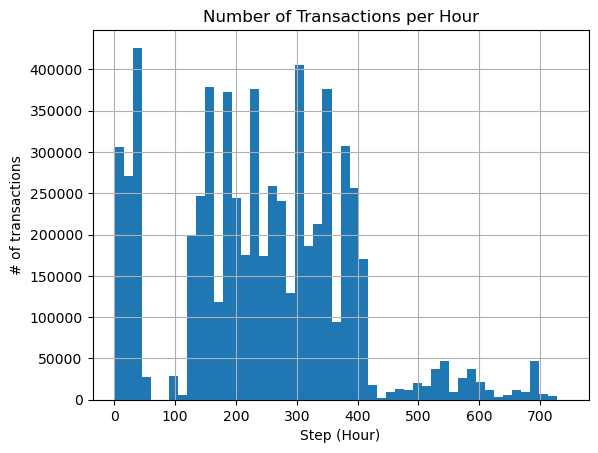

In [7]:
df['step'].hist(bins=50)
plt.title("Number of Transactions per Hour")
plt.xlabel("Step (Hour)")
plt.ylabel("# of transactions")

The distribution of transactions across 'step' reveals a pattern but not consistent, suggesting that there are varying periods of high and low banking activity, potentially mimicking real-world time/day behaviors. Worth investigating, specially against 'isFraud'

#### **Categorical and Binary Features Analysis**


In [8]:
df['type'].value_counts() # number of transactions for each type

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

In [9]:
df['isFraud'].value_counts() # count of fraud vs non-fraud

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [10]:
df['isFlaggedFraud'].value_counts() # count of fraud flagged vs not-flagged

isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64

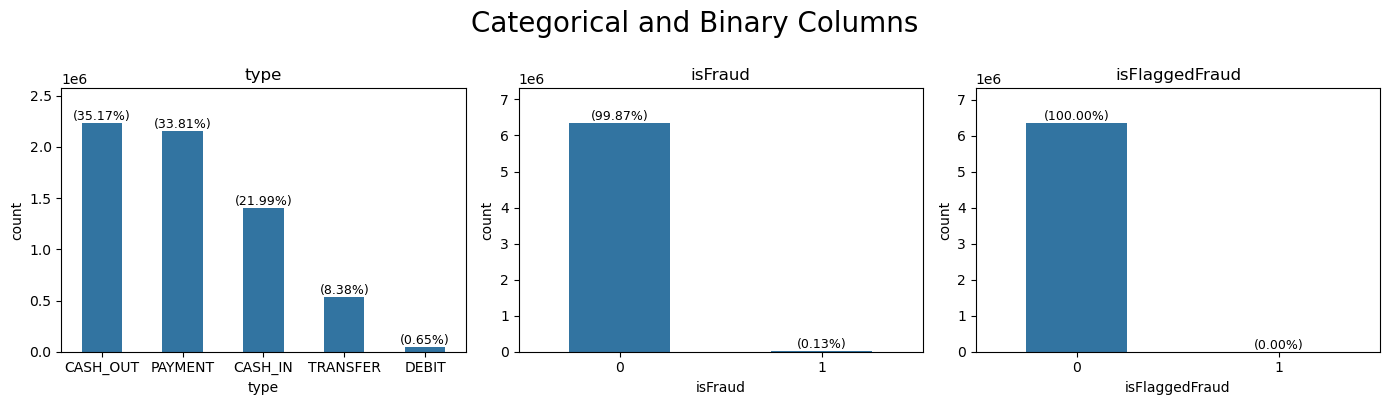

In [11]:
# Ploting categorical and binary features 
categorical_binary_columns = ['type', 'isFraud', 'isFlaggedFraud']


fig, ax = plt.subplots(1, 3, figsize=(14,4))

for i, col in enumerate(categorical_binary_columns):
    value_counts = df[col].value_counts()    
    sns.barplot(value_counts, width=0.5, ax=ax[i])
    ax[i].set_title(col)
    ax[i].margins(y=0.15)

    total = value_counts.sum()
    for bar, count in zip(ax[i].patches, value_counts):
        percentage = f"({count / total * 100:.2f}%)"
        label = f"{percentage}"
        ax[i].text(
            bar.get_x() + bar.get_width() / 2,  # x: center of bar
            bar.get_height(),                    # y: top of bar
            label,
            ha='center', va='bottom',
            fontsize=9
        )

plt.suptitle('Categorical and Binary Columns', y=1, fontsize=20)
plt.tight_layout()
plt.show()



isFraud:
- is our target variable
- There are 8213 fraud or 0.13% (imbalance)
- Because of this imbalance, model may learn that all transactions are "not fraud"

isFlaggedFraud:
- only 16 were flagged as fraud out of approx. 6 million rows - is it worth keeping this column?

type:
- Transactions with type: Debit is the least and cash_out is the most
- Wonder which types contain frauds or do they all contain fraud? Will explore this more later



#### **Numerical Features Analysis**


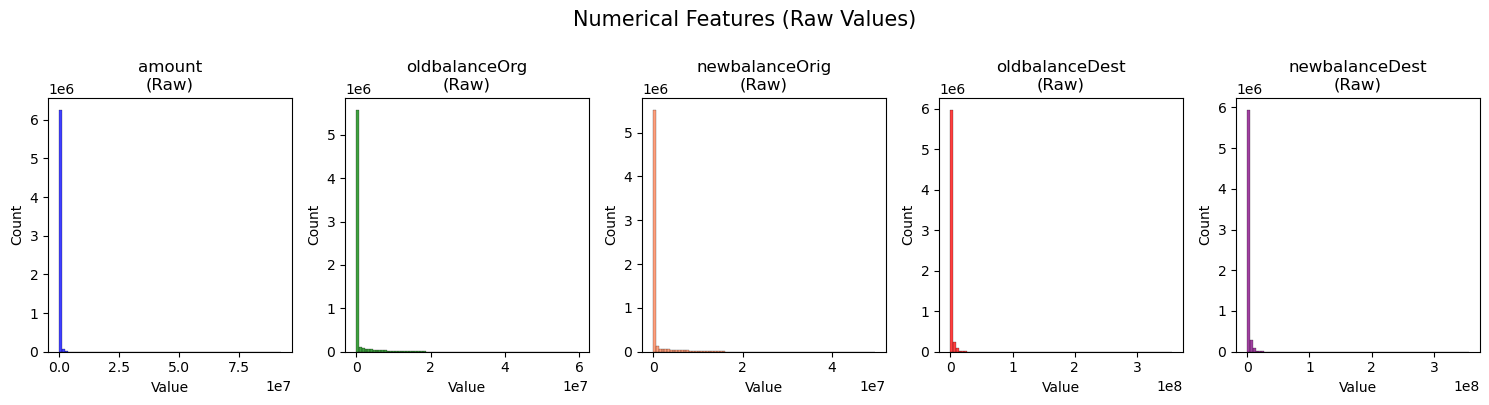

In [12]:
#Plot of numerical columns with raw values
numerical_columns = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
fig, ax = plt.subplots(1, 5, figsize=(15,4))
colors = ['blue', 'green', 'coral', 'red', 'purple']

for i, col in enumerate(numerical_columns): 
    color = colors[i]
    sns.histplot(df[col], ax=ax[i], bins=80, color=color)
    ax[i].set_title(f"{col}\n(Raw)")
    ax[i].set_xlabel(f"Value")
     

plt.suptitle('Numerical Features (Raw Values)', y=1, fontsize=15)
plt.tight_layout()
plt.show()

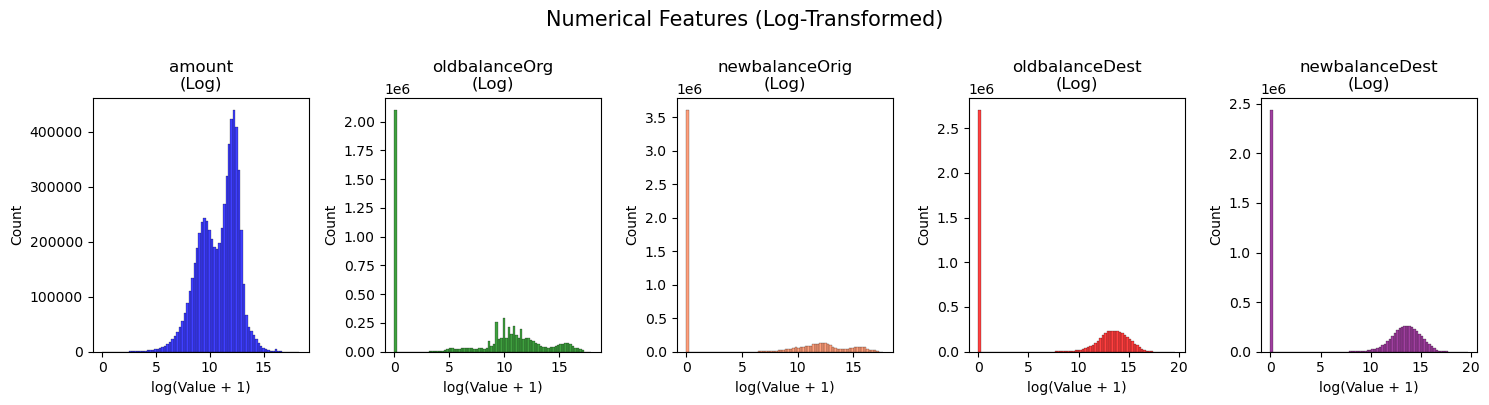

In [13]:
#Plot of numerical columns log-transformed
fig, ax = plt.subplots(1, 5, figsize=(15,4))

for i, col in enumerate(numerical_columns): 
    color = colors[i]
    sns.histplot(np.log1p(df[col]), ax=ax[i], bins=80, color=color)
    ax[i].set_title(f"{col}\n(Log)")
    ax[i].set_xlabel(f"log(Value + 1)")

plt.suptitle('Numerical Features (Log-Transformed)', y=1, fontsize=15)
plt.tight_layout()
plt.show()

As we see in the plot with raw values, all features' datapoints are heavily skewed
We applied log(Value+1) on these features to have a better sense of what the data is showing us

BALANCES:
- still showing skewness, still can distinctly tell there are spikes at zeros. SUS! Could all these be the transactions that are fraud?
- Will determine if these zeros are actually suspicious through the rest of this EDA.

AMOUNT:
- look more like a normal distribution but with two peaks 
- The peaks could mean two different types of transactions. (The smaller peak could explain regular everyday payments while the other peak may be for situations like making a downpayment for acquiring a house.)

## Bivariate Analysis

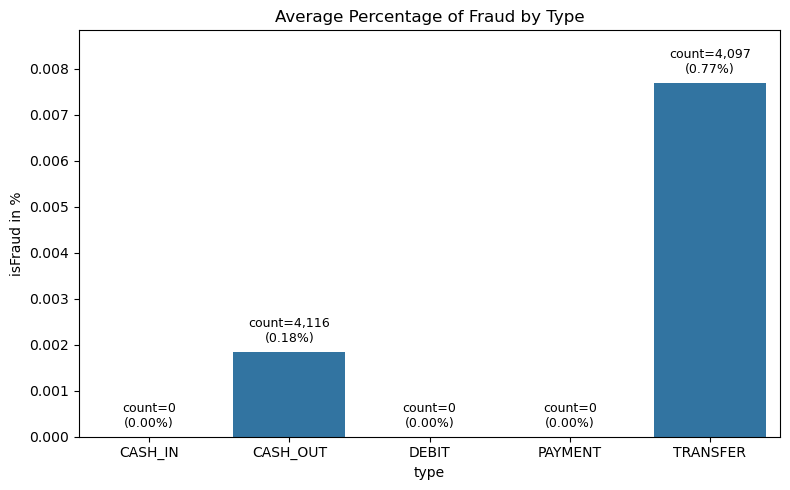

In [14]:
# type vs isFraud - check which type of transactions had fraud
fraud_mean = df.groupby('type')['isFraud'].mean()
fraud_count = df.groupby('type')['isFraud'].sum()


plt.figure(figsize=(8, 5))
ax = sns.barplot(x=fraud_mean.index, y=fraud_mean.values)
ax.margins(y=0.15)

# Add count/percentage labels on top of each bar
for bar, (mean_val, type_name) in enumerate(zip(fraud_mean.values, fraud_mean.index)):
    count = fraud_count[type_name]
    percentage = mean_val * 100
    ax.text(
        bar,
        mean_val + max(fraud_mean.values) * 0.02,
        f"count={count:,}\n({percentage:.2f}%)",
        ha='center', va='bottom', fontsize=9, color='black'
    )

plt.title("Average Percentage of Fraud by Type")
plt.xlabel("type")
plt.ylabel("isFraud in %")
plt.tight_layout()
plt.show()

Fraud only happens during transactions that are of type: CASH_OUT and TRANSFER.

TRANSFER 
- has higher fraud rate at 0.77% compared to CASH_OUT

CASH_OUT 
- only has 0.18% fraud rate
- Its important to note thought that this type still has a little bit more total fraud count, this makes sense because as we found earlier, this type is the most common transaction across all other types.

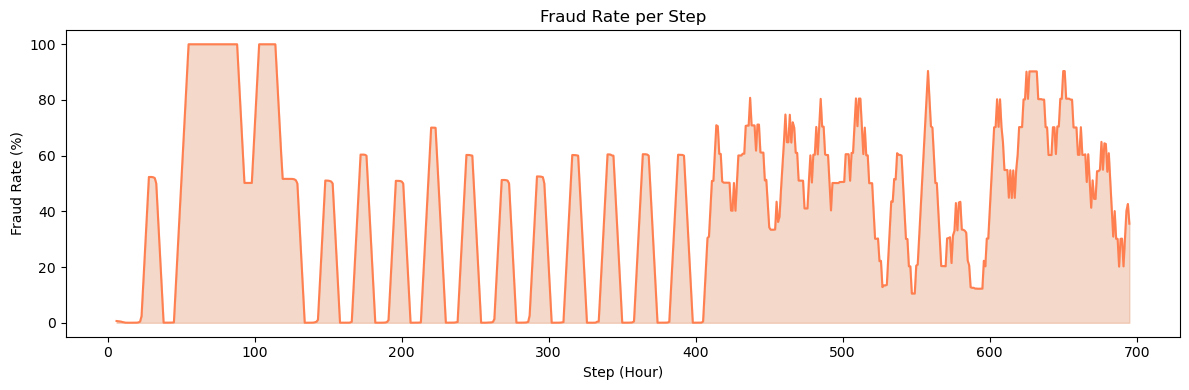

In [15]:
# Step vs isFraud
fig, ax = plt.subplots(figsize=(12, 4))

fraud_by_step = df[df['isFraud']==1].groupby('step').size().reindex(range(1, 700), fill_value=0)

total_by_step = df.groupby('step').size().reindex(range(1, 700), fill_value=1)
fraud_rate_step = (fraud_by_step / total_by_step * 100).rolling(10, center=True).mean()

ax.plot(fraud_rate_step.index, fraud_rate_step.values, color='coral', linewidth=1.5)
ax.fill_between(fraud_rate_step.index, fraud_rate_step.values, alpha=0.3, color='#DD8452')


ax.set_title('Fraud Rate per Step', fontsize=12)
ax.set_xlabel('Step (Hour)')
ax.set_ylabel('Fraud Rate (%)')

plt.tight_layout()
plt.show()

Plotting 'isFraud' vs 'step' shows that although we found some repating spiking pattern, they're mostly random highs and lows.
- Rates hitting 100% at around 30-100 hour is not consistent with our previous plot. At some point between these hours, there were very few transactions happening, but somehow fraud rate is at 100%.
- After 400, the plot becomes even more ragged and not consistent

'step' may not contribute meaningfully to our model performance.

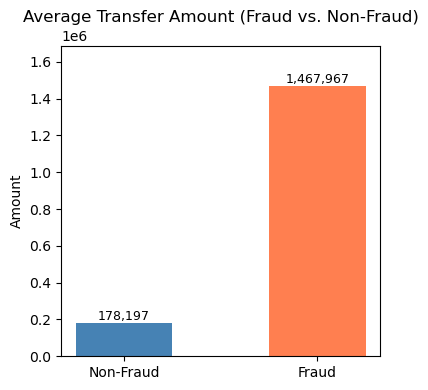

In [16]:
# amount vs isFraud
mean_amount_by_fraud = df.groupby('isFraud')['amount'].mean()

colors = ['steelblue', 'coral']

fig, ax = plt.subplots(figsize=(4, 4))
bars = ax.bar(['Non-Fraud', 'Fraud'], mean_amount_by_fraud.values, color=colors, width=0.5)
ax.margins(y=0.15)

# Add value labels on top of each bar
for bar, value in zip(bars, mean_amount_by_fraud.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
        bar.get_height(),                    # y position (top of bar)
        f"{value:,.0f}",                     # formatted label
        ha='center', va='bottom', fontsize=9, color='black'
    )

plt.title("Average Transfer Amount (Fraud vs. Non‑Fraud)", fontsize=12)
plt.ylabel("Amount")
plt.tight_layout()
plt.show()

In this graph, there's a stark difference in the transaction amounts in fraud vs non-fraud. Fraudsters are moving a much larger amount (approximately 8x more) than regular bank users, this difference makes 'amount' such a strong predictor. 

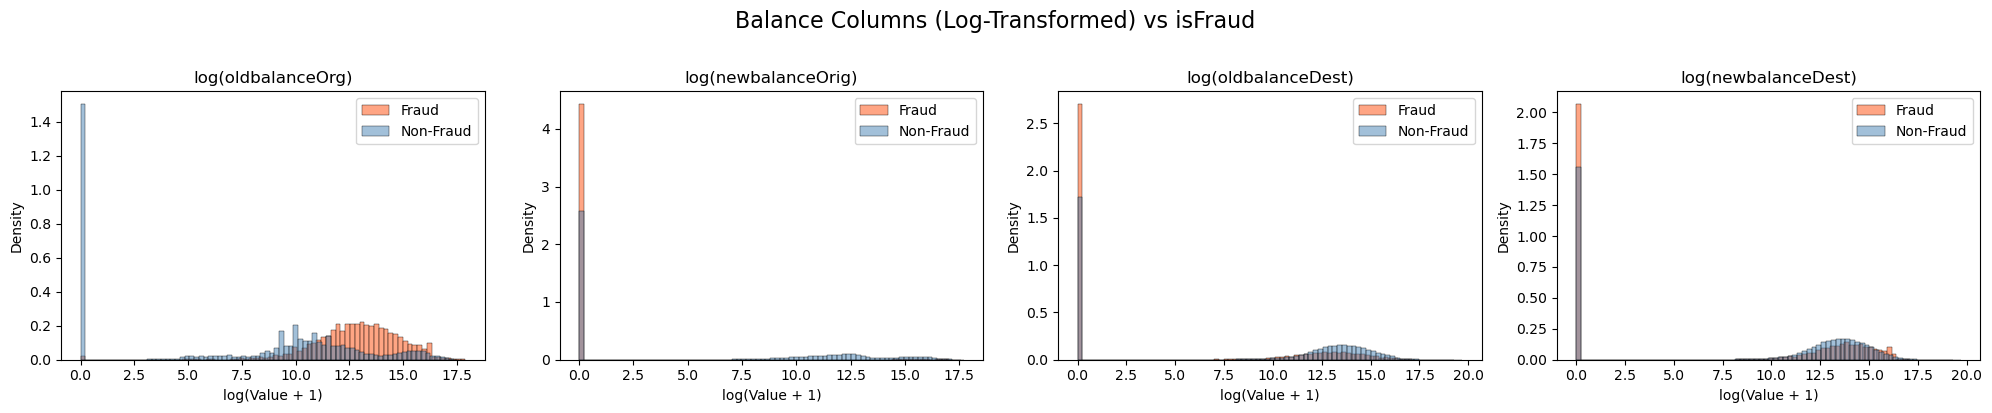

In [17]:
# Balances vs isFraud
cols = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

fig, ax = plt.subplots(1, 4, figsize=(20, 4))

for i, col in enumerate(cols):
    #Fraud
    sns.histplot(
        data=df[df['isFraud'] == 1],
        x=np.log1p(df[df['isFraud'] == 1][col]),
        ax=ax[i],
        bins=80,
        kde=False,
        color='coral',
        alpha=0.7,
        stat='density',
        label='Fraud'
    )
    #Non-Fraud
    sns.histplot(
        data=df[df['isFraud'] == 0],
        x=np.log1p(df[df['isFraud'] == 0][col]),
        ax=ax[i],
        bins=80,
        kde=False,
        color='steelblue',
        alpha=0.5,
        stat='density',
        label='Non-Fraud'
    )

    ax[i].set_title(f"log({col})", fontsize=12)
    ax[i].set_xlabel("log(Value + 1)")
    ax[i].set_ylabel("Density")
    ax[i].legend()

plt.suptitle('Balance Columns (Log-Transformed) vs isFraud', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

oldBalanceOrg (origin/before) 
- Fraudulent transactions start with huge balances
- VERY FEW start at zero compare to non-fraudulent transactions' balances.

newBalanceOrig (origin/after) 
- **All** fraudulent transactions end with zero or are empty after. 
- Legitimate transactions show similar behavior but about 50% less likely and only real transactions have some balance left in their accounts.

oldbalanceDest (destination/before) 
- Fraudsters transfer amounts **more** toward accounts that have no starting balance as the spike at zero suggests, non-fraud shows similar behavior but about 30-40% less than fraud. 
- Both fraud and non-fraud also show transactions toward accounts with existing balances but real transactions dominate that range.

newbalanceDest (destination/after) 
- A lot of the fraudulent transactions remained at zero even after some balance has been transferred. 
- Some fraudulent transactions do result in a remaining balance, similar to legitimate ones, but the proportion staying at zero is far greater for fraud than for non-fraud.

<br>

**BASICALLY...** \
<br>
Even though our data is really skewed, with the help of log-transform, we were able to pinpoint some suspicious behaviors that presents a stark difference when compared with real transactions:
- in newBalanceOrig, we find that fraudsters do not keep money in their account after transferring.
- oldBalanceOrg could also be useful, suggesting that *most* fraudsters start accounts with huge amounts.

## Multivariate Analysis

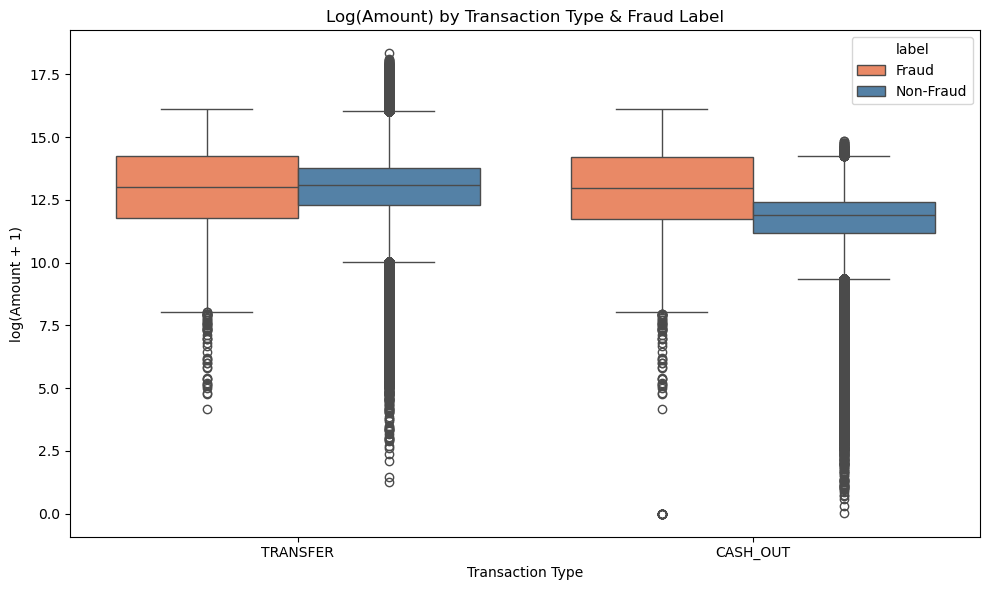

In [18]:
# AMOUNT VS TYPE VS FRAUD
plot_df = df[(df['type'] == 'TRANSFER') | (df['type'] == 'CASH_OUT')].copy()

plot_df['label'] = plot_df['isFraud'].map({0: 'Non-Fraud', 1: 'Fraud'})
plot_df['log_amount'] = np.log1p(plot_df['amount'])



plt.figure(figsize=(10, 6))

sns.boxplot(data=plot_df, x='type', y='log_amount', hue='label',
            palette={'Non-Fraud': 'steelblue', 'Fraud': 'coral'})

plt.title('Log(Amount) by Transaction Type & Fraud Label')
plt.xlabel('Transaction Type')
plt.ylabel('log(Amount + 1)')
plt.tight_layout()
plt.show()

TRANSFER:
- 'amount' alone does not help differentiate fraud from non-fraud as we can see the mean and IQR are almost at the same/similar places.

CASH_OUT:
- 'amount' is slightly higher in fraud than non-fraud transactions

This confirms that 'type' and 'amount' together could be more predictive than if looked at individually.

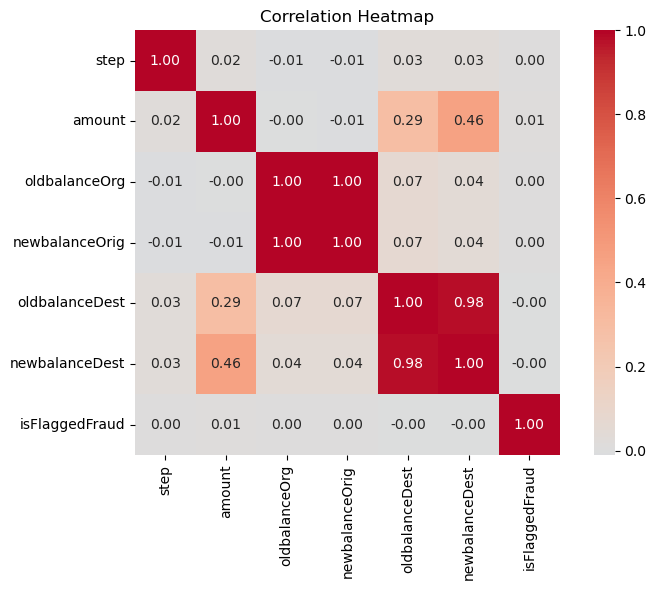

In [19]:
# Correlations of numerical features
plt.figure(figsize=(8,6))
corr = df.drop(columns=['isFraud']).corr(numeric_only=True)

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

'isFraud' doesn't have strong correlations with the features
- showing close to no linear relationship with columns by themselves. 
- The strongest are 'amount' at 0.08 and 'step' at 0.03.


'oldbalanceOrg' and 'newbalanceOrig' have high correlation at 1 
- showing multicollinearity. Will most likely drop 'oldbalanceOrg' as the other showed more distinction between fraud and non-fraud.


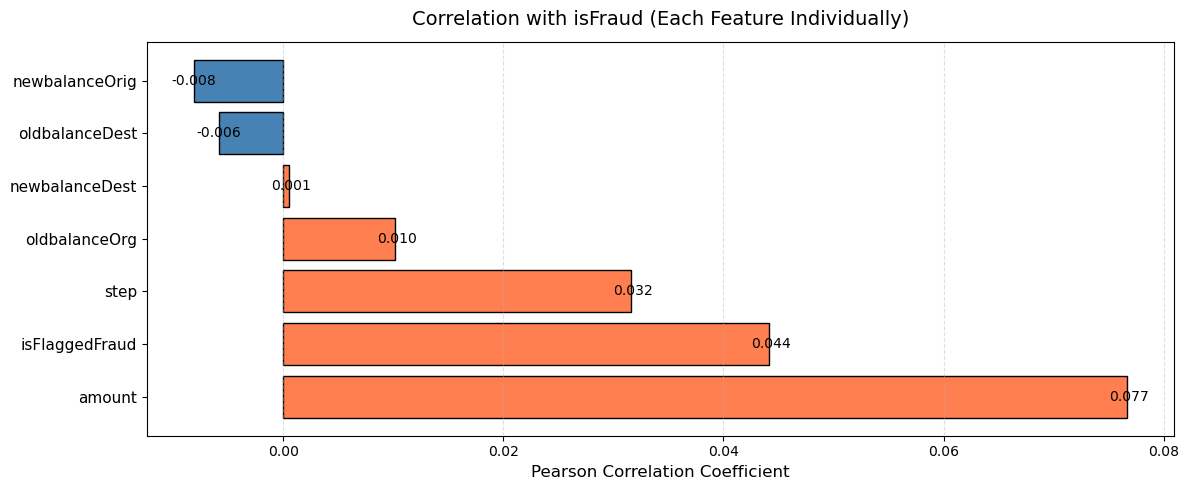

In [20]:
# Compute correlations with isFraud
corr = (
    df.corr(numeric_only=True)["isFraud"]
      .drop("isFraud")
      .sort_values(ascending=False)
)

features = corr.index
values = corr.values

# Colors: orange for positive, blue for negative
colors = ["coral" if v >= 0 else "steelblue" for v in values]

plt.figure(figsize=(12, 5))

y_pos = np.arange(len(features))

plt.barh(y_pos, values, color=colors, edgecolor="black")
plt.yticks(y_pos, features, fontsize=11)
plt.xlabel("Pearson Correlation Coefficient", fontsize=12)
plt.title("Correlation with isFraud (Each Feature Individually)", fontsize=14, pad=12)

# Light vertical grid for readability
plt.grid(axis="x", linestyle="--", alpha=0.4)

# Add value labels at the end of each bar
for i, v in enumerate(values):
    plt.text(
        v + (0.002 if v >= 0 else -0.002),
        i,
        f"{v:.3f}",
        va="center",
        ha="right" if v >= 0 else "left",
        fontsize=10
    )

plt.tight_layout()
plt.show()


Here's a better view of the correlation of isFraud against the other features.
<br>
<br>
Intuitively, fraudsters would try their best to not have the same behaviors as it'll be easier to get caught and that's what our data is saying as well. It's harder to catch fraudulent transactions by looking at just one feature. That said, models like Random Forest and Gradient Boosting will help us mitigate this issue.

---

## Hypothesis
Based on this EDA, we assume that these features carry some predictive patterns that separate fraud from non-fraud transactions.
- **type:** 
    - were able to narrow our focus to CASH_OUT and TRANSFER, eliminating the remaining three transaction types from fraud consideration.
- **amount:** 
    - the average transaction amount for fraud is about 8x higher than real transactions. This is especially highlighted in CASH_OUT transactions where fraud and non-fraud amounts separate more clearly than in TRANSFER.
- **newBalanceOrig:** 
    - was the most predictive out of all the balances features, almost all of fraud cases had zero balance after a transaction.
- **oldBalanceOrg:** 
    - very few fraudulent transactions had no balance in accounts
<br>
<br>
<br>


We also find that individual correlations with isFraud were all low, combinations of these features showed a little bit more predictive value. On the other hand, here are some of the features we did not find very useful.
- **step:** 
    - no consistent pattern
- **nameOrig & nameDest:** 
    - just unique strings to ID the transactions
- **isFlaggedFraud:** 
    - only 16 out of 8,213 fraud cases were flagged, not very helpful



---

#NOTES:

- TRAIN-TEST SPLIT PART
Positive and negative class is maintained once we split
Setting stratify=True

Target remains the same, proportioning to 
Training = 99% fraud, 1% fraud
Test = 99% fraud, 1% fraud


- Use ensemble methods for model
- do readme after project
- talk about results on readme

- dont use standardizing on random forest




README
------------ NOTE TO SELF:
- add photos of normal transfer, of sender balance weird, receiver's balance weird
- 
